In [162]:
import emcee
import matplotlib.pyplot as plt
import pyccl as ccl
import numpy as np
import corner
from IPython.display import display, Math
import matplotlib.colors as mcolors
import matplotlib
from scipy.stats import norm
from nautilus import Sampler, Prior
import h5py
print(emcee.__version__)

3.1.6


In [163]:

# Define cosmology
cosmo_universe = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)

value1 = [cosmo_universe["Omega_m"],
          cosmo_universe["Omega_b"]*cosmo_universe["h"]**2, 
          cosmo_universe["h"],
          np.log(1e10*cosmo_universe["A_s"]),
          cosmo_universe["n_s"],
          0.0,
          0.0,
          1.72,
         -0.41]

value2 = [cosmo_universe["Omega_m"],
          cosmo_universe["Omega_b"]*cosmo_universe["h"]**2, 
          cosmo_universe["h"],
          np.log(1e10*cosmo_universe["A_s"]),
          cosmo_universe["n_s"],
          0.0,
          1.72,
         -0.41]

print(np.log(1e10*cosmo_universe["A_s"]))

3.0407056391967218


In [164]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.serif": ["CMU Serif", "DejaVu Serif"]
})

### Convergence tests

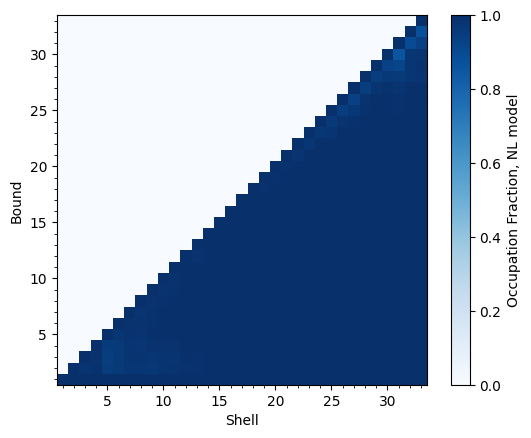

In [109]:
def log_probability_function(pars):
    return
prior = Prior()
prior.add_parameter("x", dist=norm(0,1))
prior.add_parameter("y", dist=norm(0,1))

sampler = Sampler(prior, log_probability_function,
                  filepath='/home/c2042999/MGLensing/pca_emcee_runs/chains/hdf5/lsst_y1_NLmodel.hdf5', resume=True)

occ = sampler.shell_bound_occupation()

plt.imshow(occ.T, origin='lower', cmap='Blues',
           extent=(0.5, len(occ) + 0.5, 0.5, len(occ) + 0.5))
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(1))
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(1))
plt.xlabel('Shell')
plt.ylabel('Bound')
cb = plt.colorbar()
cb.set_label('Occupation Fraction, NL model')

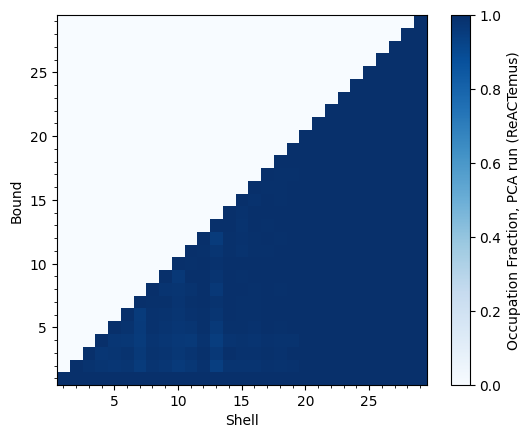

In [110]:
sampler = Sampler(prior, log_probability_function,
                  filepath='/home/c2042999/MGLensing/pca_emcee_runs/chains/hdf5/lsst_y1_pcacuts_ReACTemus.hdf5', resume=True)

occ = sampler.shell_bound_occupation()

plt.imshow(occ.T, origin='lower', cmap='Blues',
           extent=(0.5, len(occ) + 0.5, 0.5, len(occ) + 0.5))
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(1))
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(1))
plt.xlabel('Shell')
plt.ylabel('Bound')
cb = plt.colorbar()
cb.set_label('Occupation Fraction, PCA run (ReACTemus)')

## Plotting chains and contours

### Plot 1: recover NL modelling and ReACT PCA with same setup - GR

In [165]:
chain_raw_1 = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_GR_lsst_y1_pcacuts_ReACTemus.txt")
chain_RE = np.concatenate((chain_raw_1[:,:-4], 1e-5*np.random.randn(len(chain_raw_1),1), chain_raw_1[:,-4:]), axis=1)

chain_NL = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_GR_lsst_y1_NLmodel.txt")

labels1 = [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$q_1$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]


0.3598591364540418 0.28001762182886036
0.023564368038359138 0.02068017828879215
0.7299631449217142 0.6100646037799481
3.2188223693417273 2.833603177409235
0.9779997077496813 0.9465730578158368
1.4944598719481252 -1.4997825294040656
3.7536961085097636e-05 -4.104636427535951e-05
12.050294485215675 0.014706815854304377
6.135953156282392 -6.9986333195545205


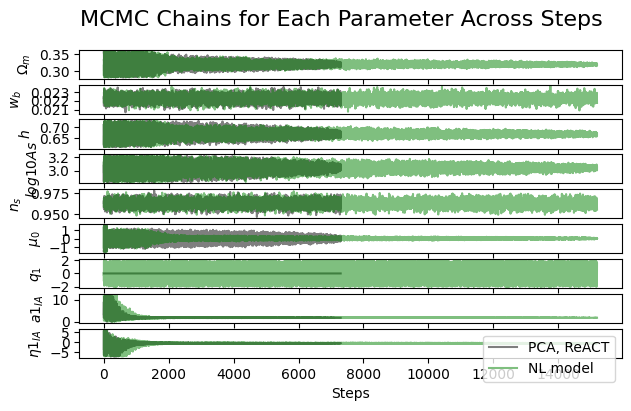

In [166]:
# Assuming `raw_chain` is the MCMC chain you have loaded from the file.

# Create a figure with subplots, one for each parameter
fig, axes = plt.subplots(len(chain.T)-2, figsize=(7, 4), sharex=True)

# Iterate over each parameter and plot its evolution
for i in range(len(chain.T)-2):
    ax = axes[i]
    ax.plot(chain_RE[:, i], alpha=0.5, color="k")  # Plot for each walker
    ax.plot(chain_NL[:, i], alpha=0.5, color="g")  # Plot for each walker
    #ax.plot(chain_raw_NLmodel[:, i], alpha=0.5, color="r")  # Plot for each walker
    print(max(chain_RE[:, i]),min(chain_RE[:, i]))
    ax.set_ylabel(labels1[i])

# Add a label for the shared x-axis (steps/iterations)
axes[-1].set_xlabel("Steps")

# Set the overall title and adjust layout
plt.suptitle("MCMC Chains for Each Parameter Across Steps", fontsize=16)
plt.legend(["PCA, ReACT","NL model"])
# Show the plot
#plt.savefig("chains_ESS-C_noparametrization.pdf", bbox_inches='tight')
plt.show()

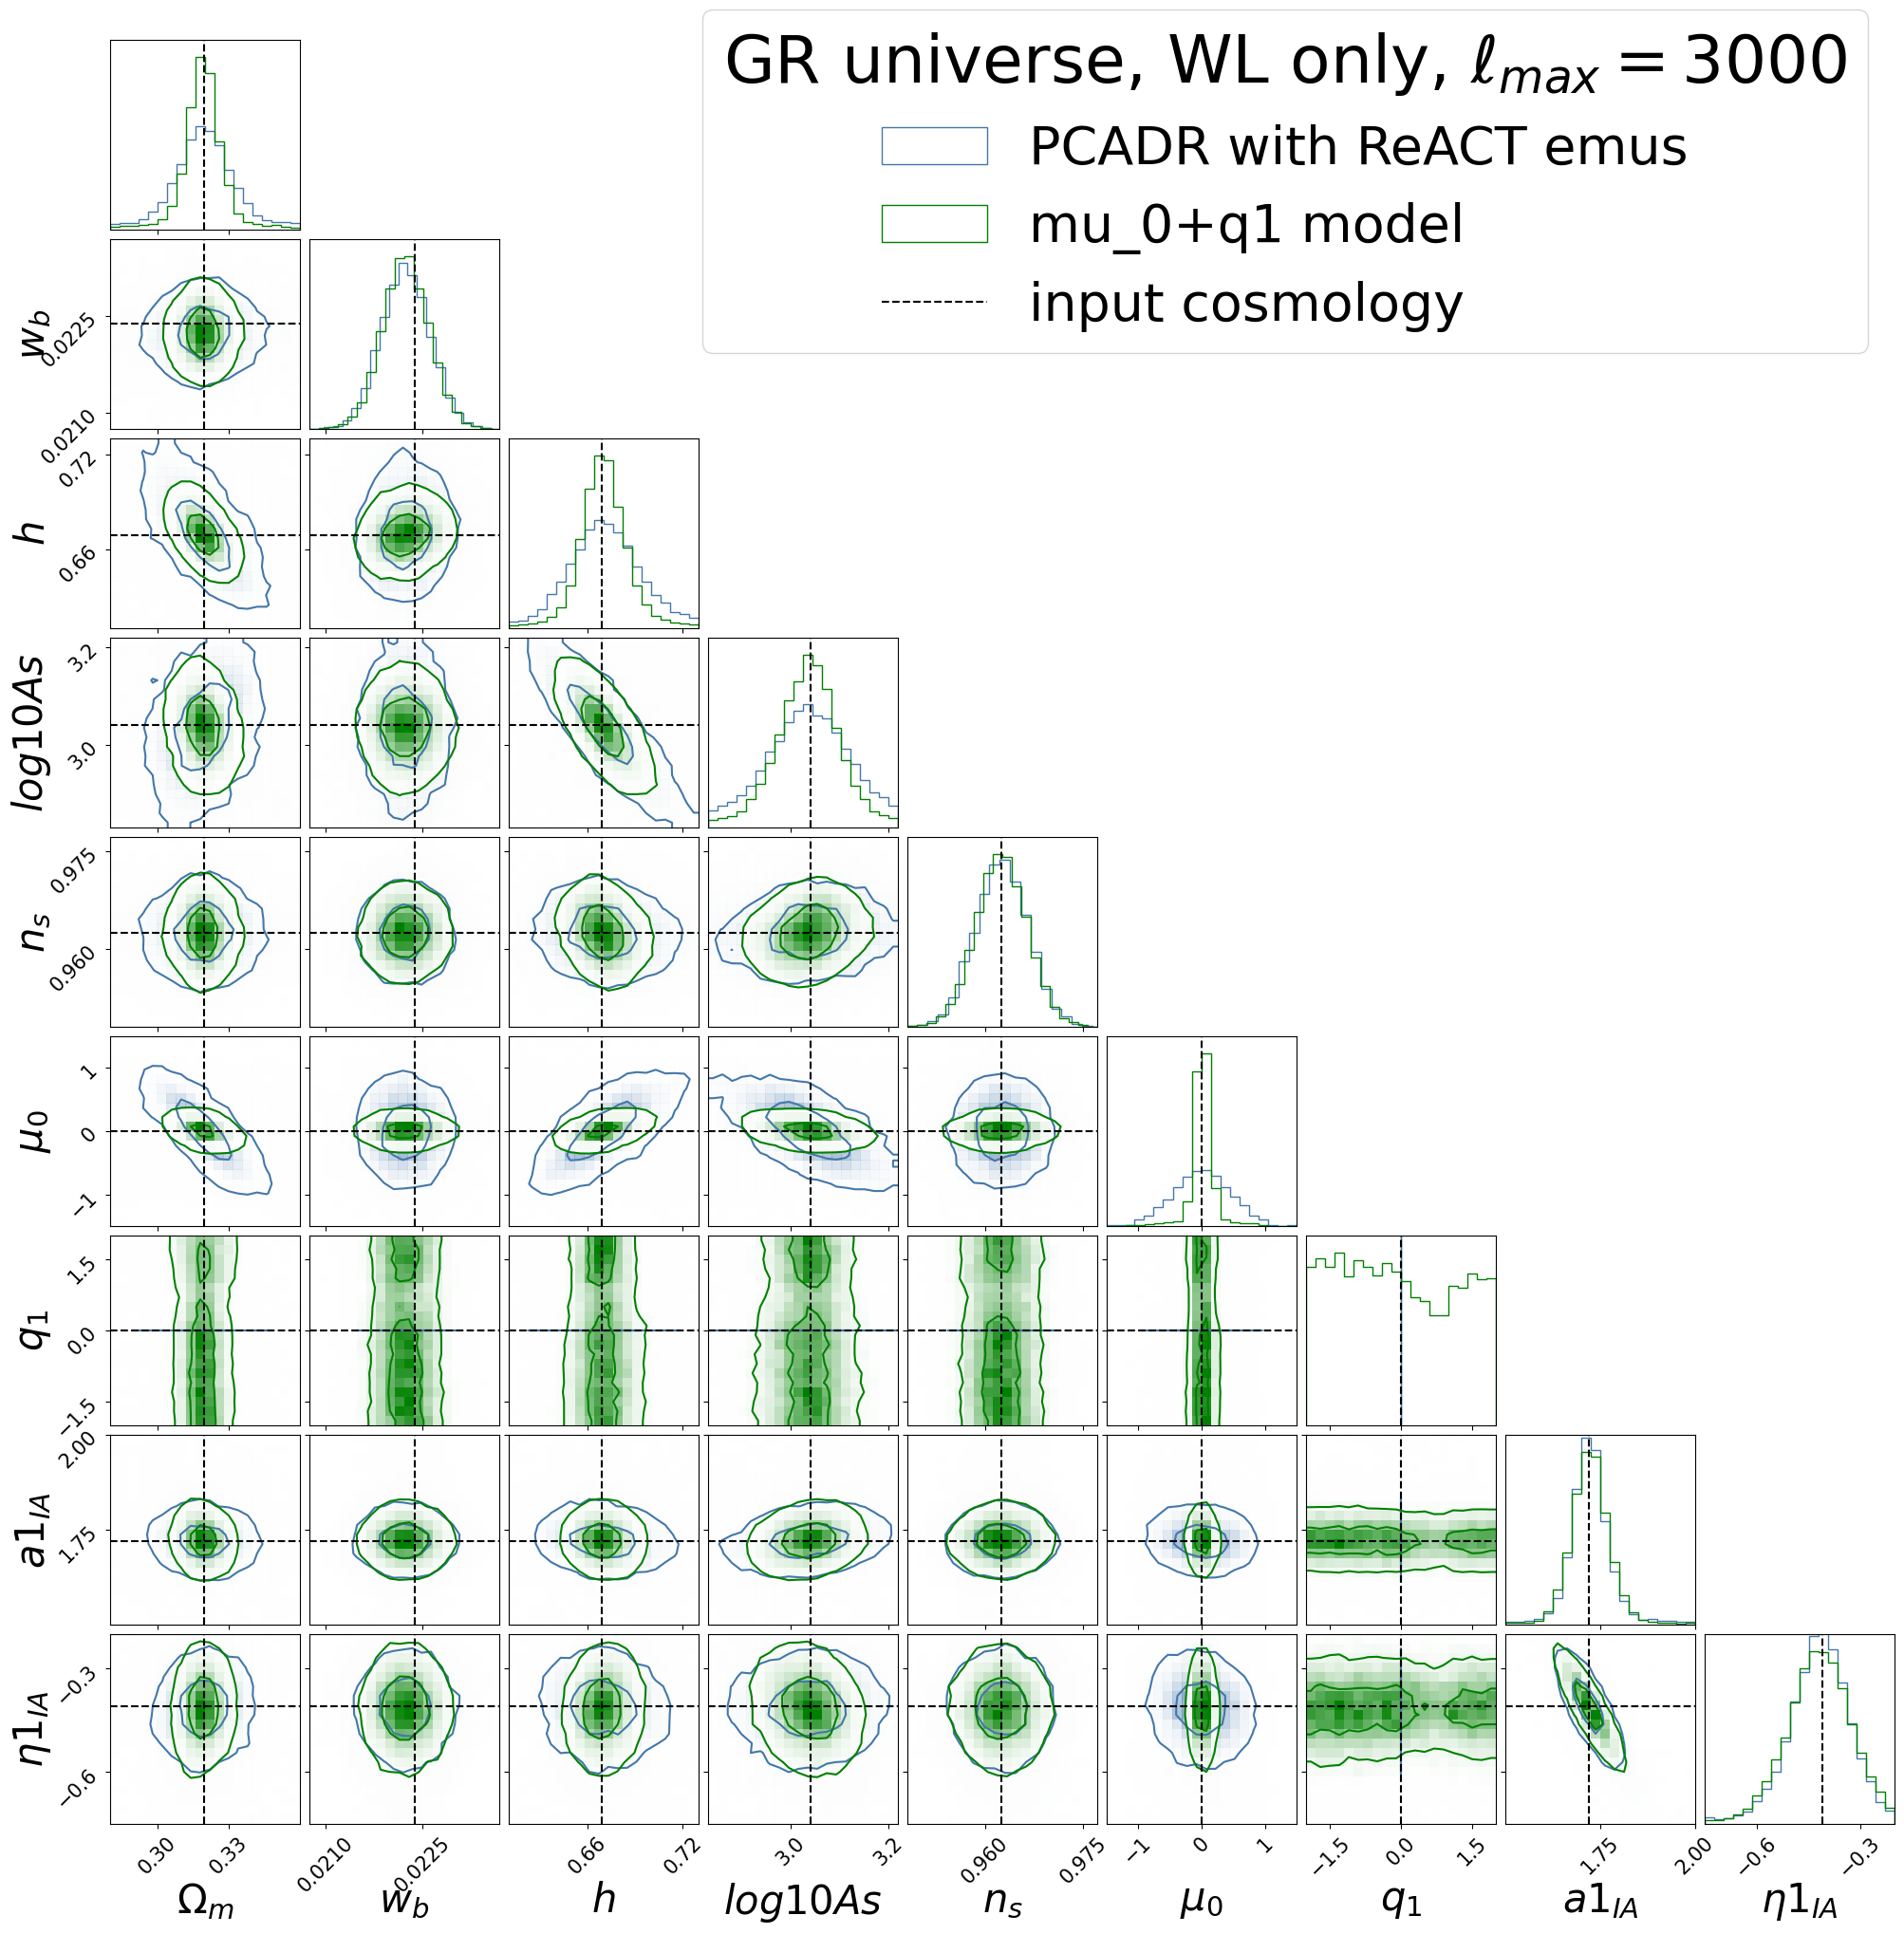

In [167]:
#### STANDARD CUTS #####
ndim = 9
n_params = 9
colors = ["#4477AA","green"]  # Contour colors
truth_color = "k"  # Truth values

ranges = [1.0] * chain[:,:-2].shape[1]
ranges[-2] = (1.5, 2)
ranges[-1] = (-0.75, -0.2)

CORNER_KWARGS = dict(
    range=ranges,
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

figure = corner.corner(chain_RE[:,:-2], labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[0])

corner.corner(chain_NL[:,:-2], fig=figure, labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[1])



######################
# Extract the axes


axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
########################

for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size

#plt.legend(["3x2pt, Existing method (linear scale cuts)","maximum likelihood \n (for PCA-based cuts)","3x2pt, Our method (PCA-based cuts)","input cosmology"],\
#           bbox_to_anchor=(1.0, 12.7), fontsize=40,title=r"GR universe",title_fontsize=60)
plt.legend(["PCADR with ReACT emus","mu_0+q1 model", "input cosmology"], bbox_to_anchor=(1.0, 9.7), fontsize=40,title=r"GR universe, WL only, $\ell_{max}=3000$",title_fontsize=50)
#"maximum likelihood \n (for PCA-based cuts)"
#plt.savefig("/home/c2042999/MGLensing/pca_emcee_runs/Figures/WL_GR_PCAReACT_NLmodel.pdf", bbox_inches='tight')


### Plot 2: recover NL modelling and ReACT PCA with same setup - f(R) data from ReACTEmu

In [168]:
# Datavector is from ReACT, analysis is with ReACTEmus 
chain_raw_1 = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_fR_ReactEmu_lsst_y1_pcacuts_ReACTemus.txt")
chain_RE = np.concatenate((chain_raw_1[:,:-4], 1e-5*np.random.randn(len(chain_raw_1),1), chain_raw_1[:,-4:]), axis=1)

chain_NL = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_lsst_y1_NLmodel_fR.txt")

labels1 = [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$q_1$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]

0.3599876112940469 0.28000289706292636
0.023690601088738085 0.020890254145836815
0.729839305492624 0.6100352886046321
3.2187321247360083 2.833262382008938
0.9772301645725403 0.9478511999525603
1.4140608651785662 -1.4883312002044304
3.200420547349054e-05 -3.8383892520043666e-05
11.988077425161421 0.05449775151759523
6.167568729598992 -6.982830837333421


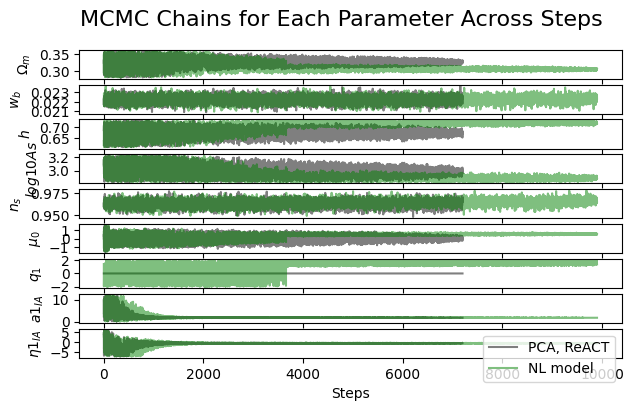

In [169]:
# Assuming `raw_chain` is the MCMC chain you have loaded from the file.

# Create a figure with subplots, one for each parameter
fig, axes = plt.subplots(len(chain.T)-2, figsize=(7, 4), sharex=True)

# Iterate over each parameter and plot its evolution
for i in range(len(chain.T)-2):
    ax = axes[i]
    ax.plot(chain_RE[:, i], alpha=0.5, color="k")  # Plot for each walker
    ax.plot(chain_NL[:, i], alpha=0.5, color="g")  # Plot for each walker
    #ax.plot(chain_raw_NLmodel[:, i], alpha=0.5, color="r")  # Plot for each walker
    print(max(chain_RE[:, i]),min(chain_RE[:, i]))
    ax.set_ylabel(labels1[i])

# Add a label for the shared x-axis (steps/iterations)
axes[-1].set_xlabel("Steps")

# Set the overall title and adjust layout
plt.suptitle("MCMC Chains for Each Parameter Across Steps", fontsize=16)
plt.legend(["PCA, ReACT","NL model"])
# Show the plot
#plt.savefig("chains_ESS-C_noparametrization.pdf", bbox_inches='tight')
plt.show()

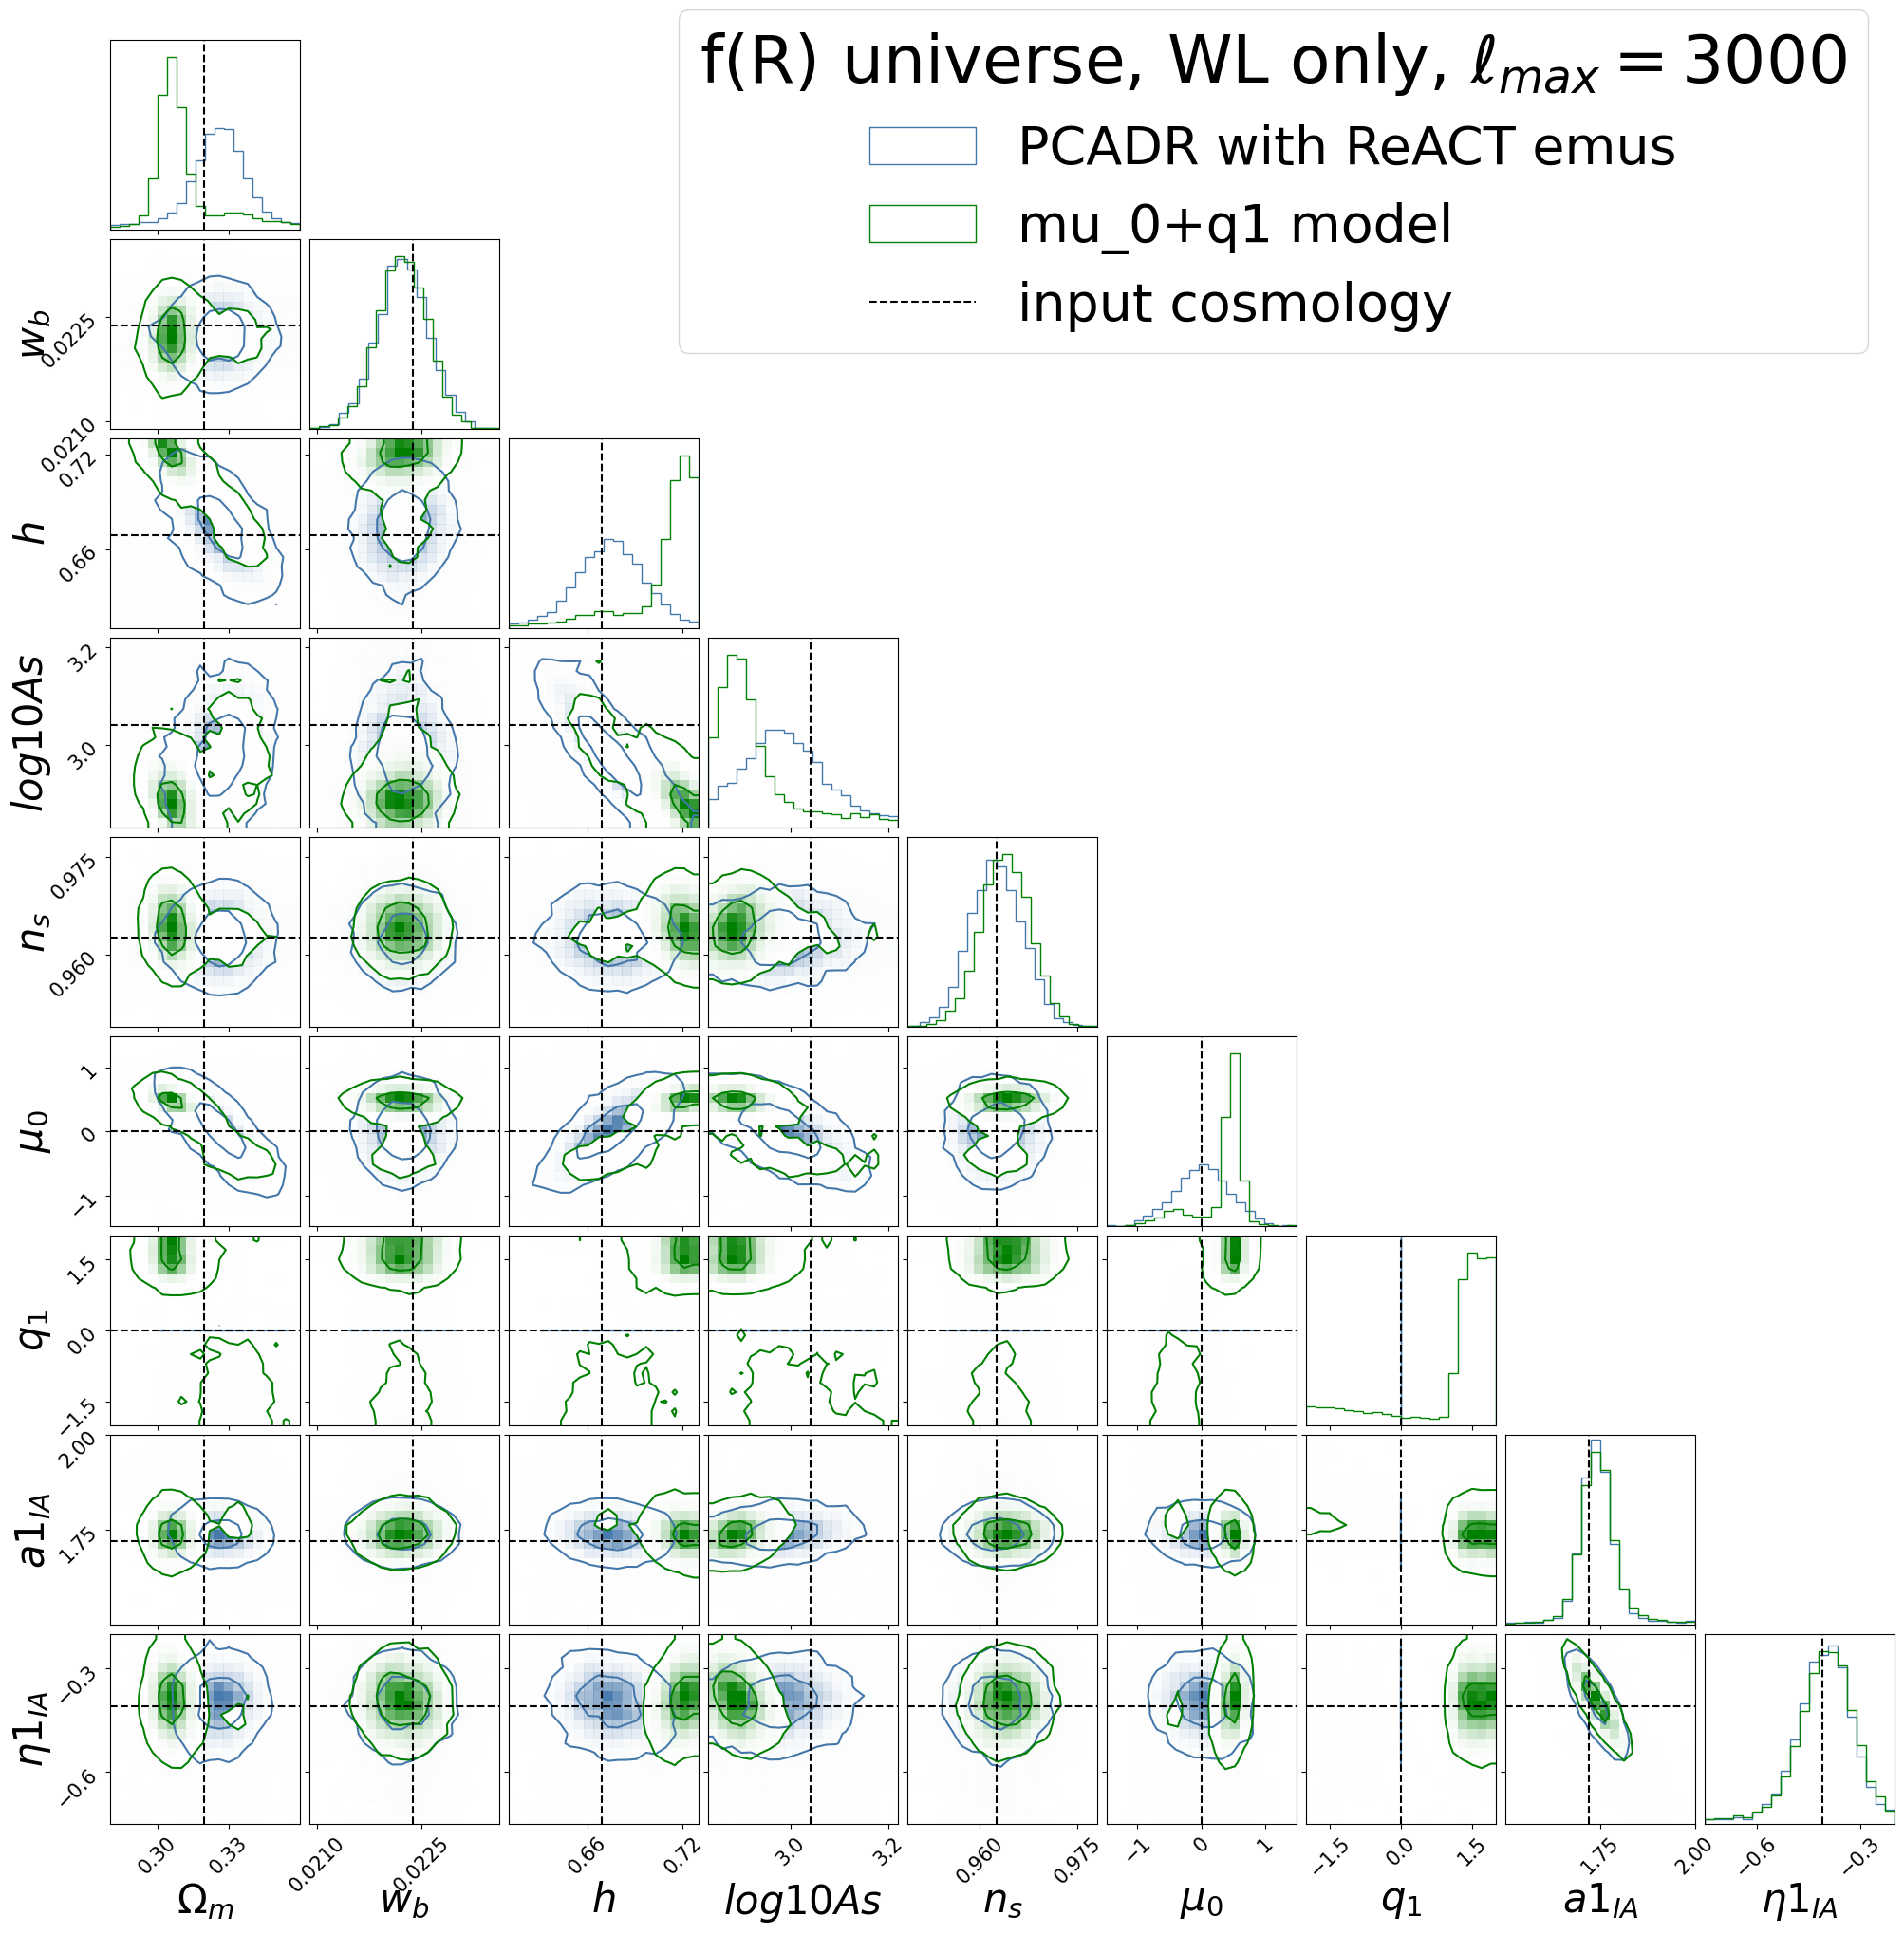

In [170]:
#### STANDARD CUTS #####
ndim = 9
n_params = 9
colors = ["#4477AA","green"]  # Contour colors
truth_color = "k"  # Truth values

ranges = [1.0] * chain[:,:-2].shape[1]
ranges[-2] = (1.5, 2)
ranges[-1] = (-0.75, -0.2)

CORNER_KWARGS = dict(
    range=ranges,
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

figure = corner.corner(chain_RE[:,:-2], labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[0])

corner.corner(chain_NL[:,:-2], fig=figure, labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[1])



######################
# Extract the axes


axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value1[xi], color=truth_color, linestyle="--")
            ax.axhline(value1[yi], color=truth_color, linestyle="--")
########################

for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size

#plt.legend(["3x2pt, Existing method (linear scale cuts)","maximum likelihood \n (for PCA-based cuts)","3x2pt, Our method (PCA-based cuts)","input cosmology"],\
#           bbox_to_anchor=(1.0, 12.7), fontsize=40,title=r"GR universe",title_fontsize=60)
plt.legend(["PCADR with ReACT emus","mu_0+q1 model", "input cosmology"], bbox_to_anchor=(1.0, 9.7), fontsize=40,title=r"f(R) universe, WL only, $\ell_{max}=3000$",title_fontsize=50)
#"maximum likelihood \n (for PCA-based cuts)"
#plt.savefig("/home/c2042999/MGLensing/pca_emcee_runs/Figures/WL_GR_PCAReACT_NLmodel.pdf", bbox_inches='tight')


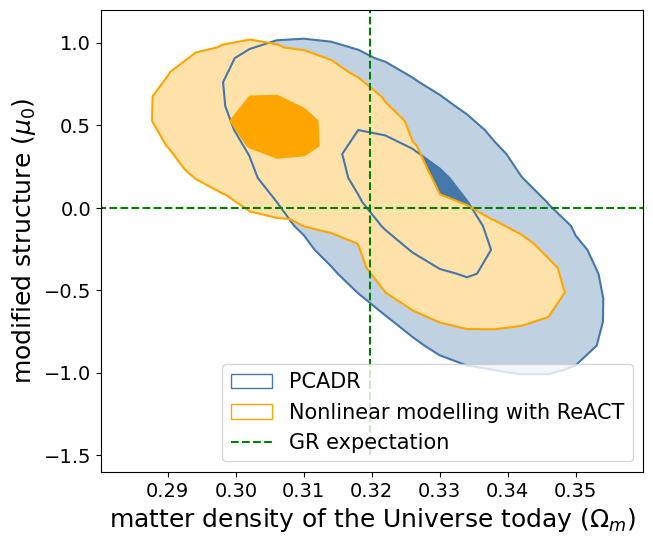

In [171]:
labels2 = [r"matter density of the Universe today ($\Omega_m$)", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"modified structure ($\mu_0$)",r"$q_1$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]

plt.figure(figsize=(7, 6))

# Indices
x_idx = 0
y_idx = 5

col = ["#4477AA","orange", "green"]  # Contour colors


##### contour 1 ######
flat_samples = chain_RE[:,:-2]

# Extract the relevant 2D samples
x_samples = flat_samples[:, x_idx]
y_samples = flat_samples[:, y_idx]

# Set up the corner plot arguments
CORNER_KWARGS_hist = dict(
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    no_fill_contours=True,
    smooth=True,
    fill_contours=True,
    max_n_ticks=3,
    label_kwargs=dict(fontsize=20),
    title_kwargs=dict(fontsize=14),
    color=mcolors.to_hex(col[0]),
    hist_kwargs=dict(density=True)
)

# Create the 2D contour plot
figure = corner.hist2d(
    x_samples, y_samples,
    labels=[labels2[x_idx], labels2[y_idx]],
    **CORNER_KWARGS_hist
)


### Contour 2 ####

flat_samples =  chain_NL[:,:-2]

# Extract the relevant 2D samples
x_samples = flat_samples[:, x_idx]
y_samples = flat_samples[:, y_idx]


CORNER_KWARGS_hist = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=True,
    smooth=True,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    #no_fill_contours=True,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f",
    color=mcolors.to_hex(col[1]),
    truths=value1[:ndim],
    truth_color="k"
)

figure = corner.hist2d(
    x_samples, y_samples,**CORNER_KWARGS_hist

)

# add GR values
plt.vlines(value1[x_idx], -1.5,1.5, color=mcolors.to_hex(col[2]), linestyle="--")
plt.hlines(value1[y_idx],-1.5,1.5, color=mcolors.to_hex(col[2]), linestyle="--")#color=mcolors.to_hex(col[4]))

plt.xlabel(labels2[x_idx], fontsize=18)
plt.ylabel(labels2[y_idx], fontsize=18)


plt.ylim(-1.6,1.2)

# Create custom legend handles
legend_handles = [
    matplotlib.patches.Patch(facecolor="none", edgecolor=mcolors.to_hex(col[0]), label="PCADR"),
    matplotlib.patches.Patch(facecolor="none", edgecolor=mcolors.to_hex(col[1]), label="Nonlinear modelling with ReACT"),
    matplotlib.lines.Line2D([], [], color=mcolors.to_hex(col[2]), label="GR expectation", linestyle="--")
    #matplotlib.lines.Line2D([], [], color=mcolors.to_hex(col[4]), label="truth")
]

# Add legend to the plot
plt.legend(
    handles=legend_handles, 
    loc="lower right", 
    fontsize=15
)

plt.tick_params(axis='both', labelsize=14) 
#plt.title(r"$f(R)$ universe", fontsize=25)

#plt.savefig("/home/c2042999/PCA_project/Figures/3x2pt_fsigma8_GR_pres_2.pdf", bbox_inches='tight')

plt.show()


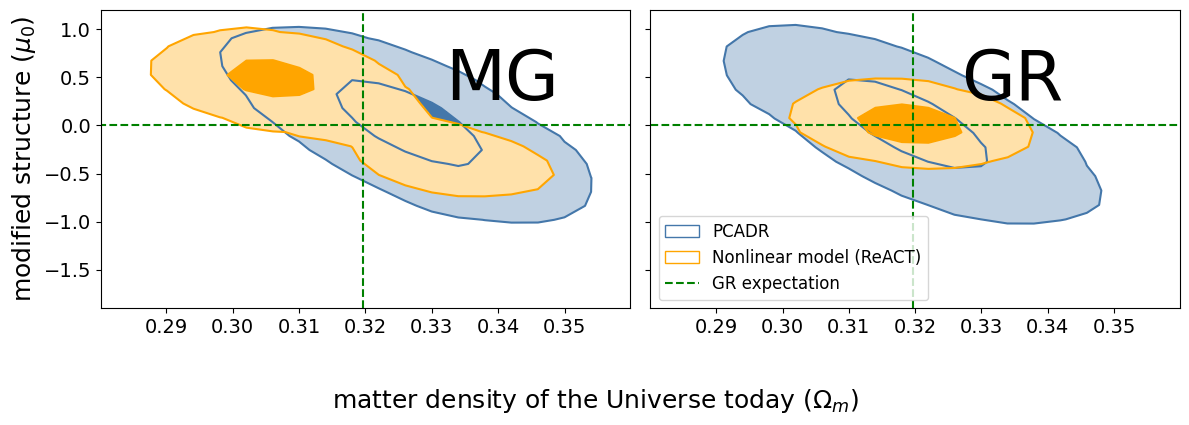

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
labels2 = [r"matter density of the Universe today ($\Omega_m$)", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"modified structure ($\mu_0$)",r"$q_1$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]

# Recover these again for the plot
chain_raw_1 = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_GR_lsst_y1_pcacuts_ReACTemus.txt")
chain_RE_GR = np.concatenate((chain_raw_1[:,:-4], 1e-5*np.random.randn(len(chain_raw_1),1), chain_raw_1[:,-4:]), axis=1)

chain_NL_GR = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_GR_lsst_y1_NLmodel.txt")


##### PLT 1 #######
# ------------------ Contour 1 ------------------
flat_samples = chain_RE[:, :-2]
x_samples = flat_samples[:, x_idx]
y_samples = flat_samples[:, y_idx]

CORNER_KWARGS_hist1 = dict(
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    no_fill_contours=True,
    smooth=True,
    fill_contours=True,
    max_n_ticks=3,
    label_kwargs=dict(fontsize=20),
    title_kwargs=dict(fontsize=14),
    color=mcolors.to_hex(col[0]),
    hist_kwargs=dict(density=True)
)

corner.hist2d(
    x_samples, y_samples,
    labels=[labels2[x_idx], labels2[y_idx]],
    ax=axes[0], 
    **CORNER_KWARGS_hist1
)
axes[0].set_ylabel(labels2[y_idx], fontsize=18)
axes[0].tick_params(axis='both', labelsize=14)


# ------------------ Contour 2 ------------------
flat_samples = chain_NL[:, :-2]
x_samples = flat_samples[:, x_idx]
y_samples = flat_samples[:, y_idx]

CORNER_KWARGS_hist2 = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=True,
    smooth=True,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f",
    color=mcolors.to_hex(col[1]),
    truths=value1[:ndim],
    truth_color="k"
)

corner.hist2d(
    x_samples, y_samples,
    ax=axes[0],
    **CORNER_KWARGS_hist2
)

# Add GR expectation lines to the right subplot
axes[0].vlines(value1[x_idx], -1.9, 1.5, color=mcolors.to_hex(col[2]), linestyle="--")
axes[0].hlines(value1[y_idx], -1.9, 1.5, color=mcolors.to_hex(col[2]), linestyle="--")


##### PLT 2 ####
# ------------------ Contour 3 ------------------
flat_samples = chain_RE_GR[:, :-2]
x_samples = flat_samples[:, x_idx]
y_samples = flat_samples[:, y_idx]

CORNER_KWARGS_hist1 = dict(
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    no_fill_contours=True,
    smooth=True,
    fill_contours=True,
    max_n_ticks=3,
    label_kwargs=dict(fontsize=20),
    title_kwargs=dict(fontsize=14),
    color=mcolors.to_hex(col[0]),
    hist_kwargs=dict(density=True)
)

corner.hist2d(
    x_samples, y_samples,
    labels=[labels2[x_idx], labels2[y_idx]],
    ax=axes[1], 
    **CORNER_KWARGS_hist1
)
axes[1].tick_params(axis='both', labelsize=14)


# ------------------ Contour 4 ------------------
flat_samples = chain_NL_GR[:, :-2]
x_samples = flat_samples[:, x_idx]
y_samples = flat_samples[:, y_idx]

CORNER_KWARGS_hist2 = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=True,
    smooth=True,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f",
    color=mcolors.to_hex(col[1]),
    truths=value1[:ndim],
    truth_color="k"
)

corner.hist2d(
    x_samples, y_samples,
    ax=axes[1],
    **CORNER_KWARGS_hist2
)



# Add GR expectation lines to the right subplot
axes[1].vlines(value1[x_idx], -1.9, 1.5, color=mcolors.to_hex(col[2]), linestyle="--")
axes[1].hlines(value1[y_idx], -1.9, 1.5, color=mcolors.to_hex(col[2]), linestyle="--")

fig.supxlabel(labels2[x_idx], fontsize=18,y=-0.05)

axes[1].tick_params(axis='both', labelsize=14)
axes[1].set_ylim(-1.9, 1.2)

# Legend only on the right subplot
legend_handles = [
    matplotlib.patches.Patch(facecolor="none", edgecolor=mcolors.to_hex(col[0]), label="PCADR"),
    matplotlib.patches.Patch(facecolor="none", edgecolor=mcolors.to_hex(col[1]), label="Nonlinear model (ReACT)"),
    matplotlib.lines.Line2D([], [], color=mcolors.to_hex(col[2]), label="GR expectation", linestyle="--")
]
axes[1].legend(handles=legend_handles, loc="lower left", fontsize=12)

fig.text(0.89, 0.87, "GR", ha="right", va="top", fontsize=50)
fig.text(0.47, 0.87, "MG", ha="right", va="top", fontsize=50)


#plt.savefig("/home/c2042999/MGLensing/pca_emcee_runs/Figures/WL_Comparison_2.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()

### Plot 3: Compare ReACTEmu PCA with ExtEmu PCA - GR

In [173]:
chain_RE = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_GR_lsst_y1_pcacuts_ext.txt")
chain_EE = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_GR_lsst_y1_pcacuts_ReACTemus.txt")

labels1 = [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]

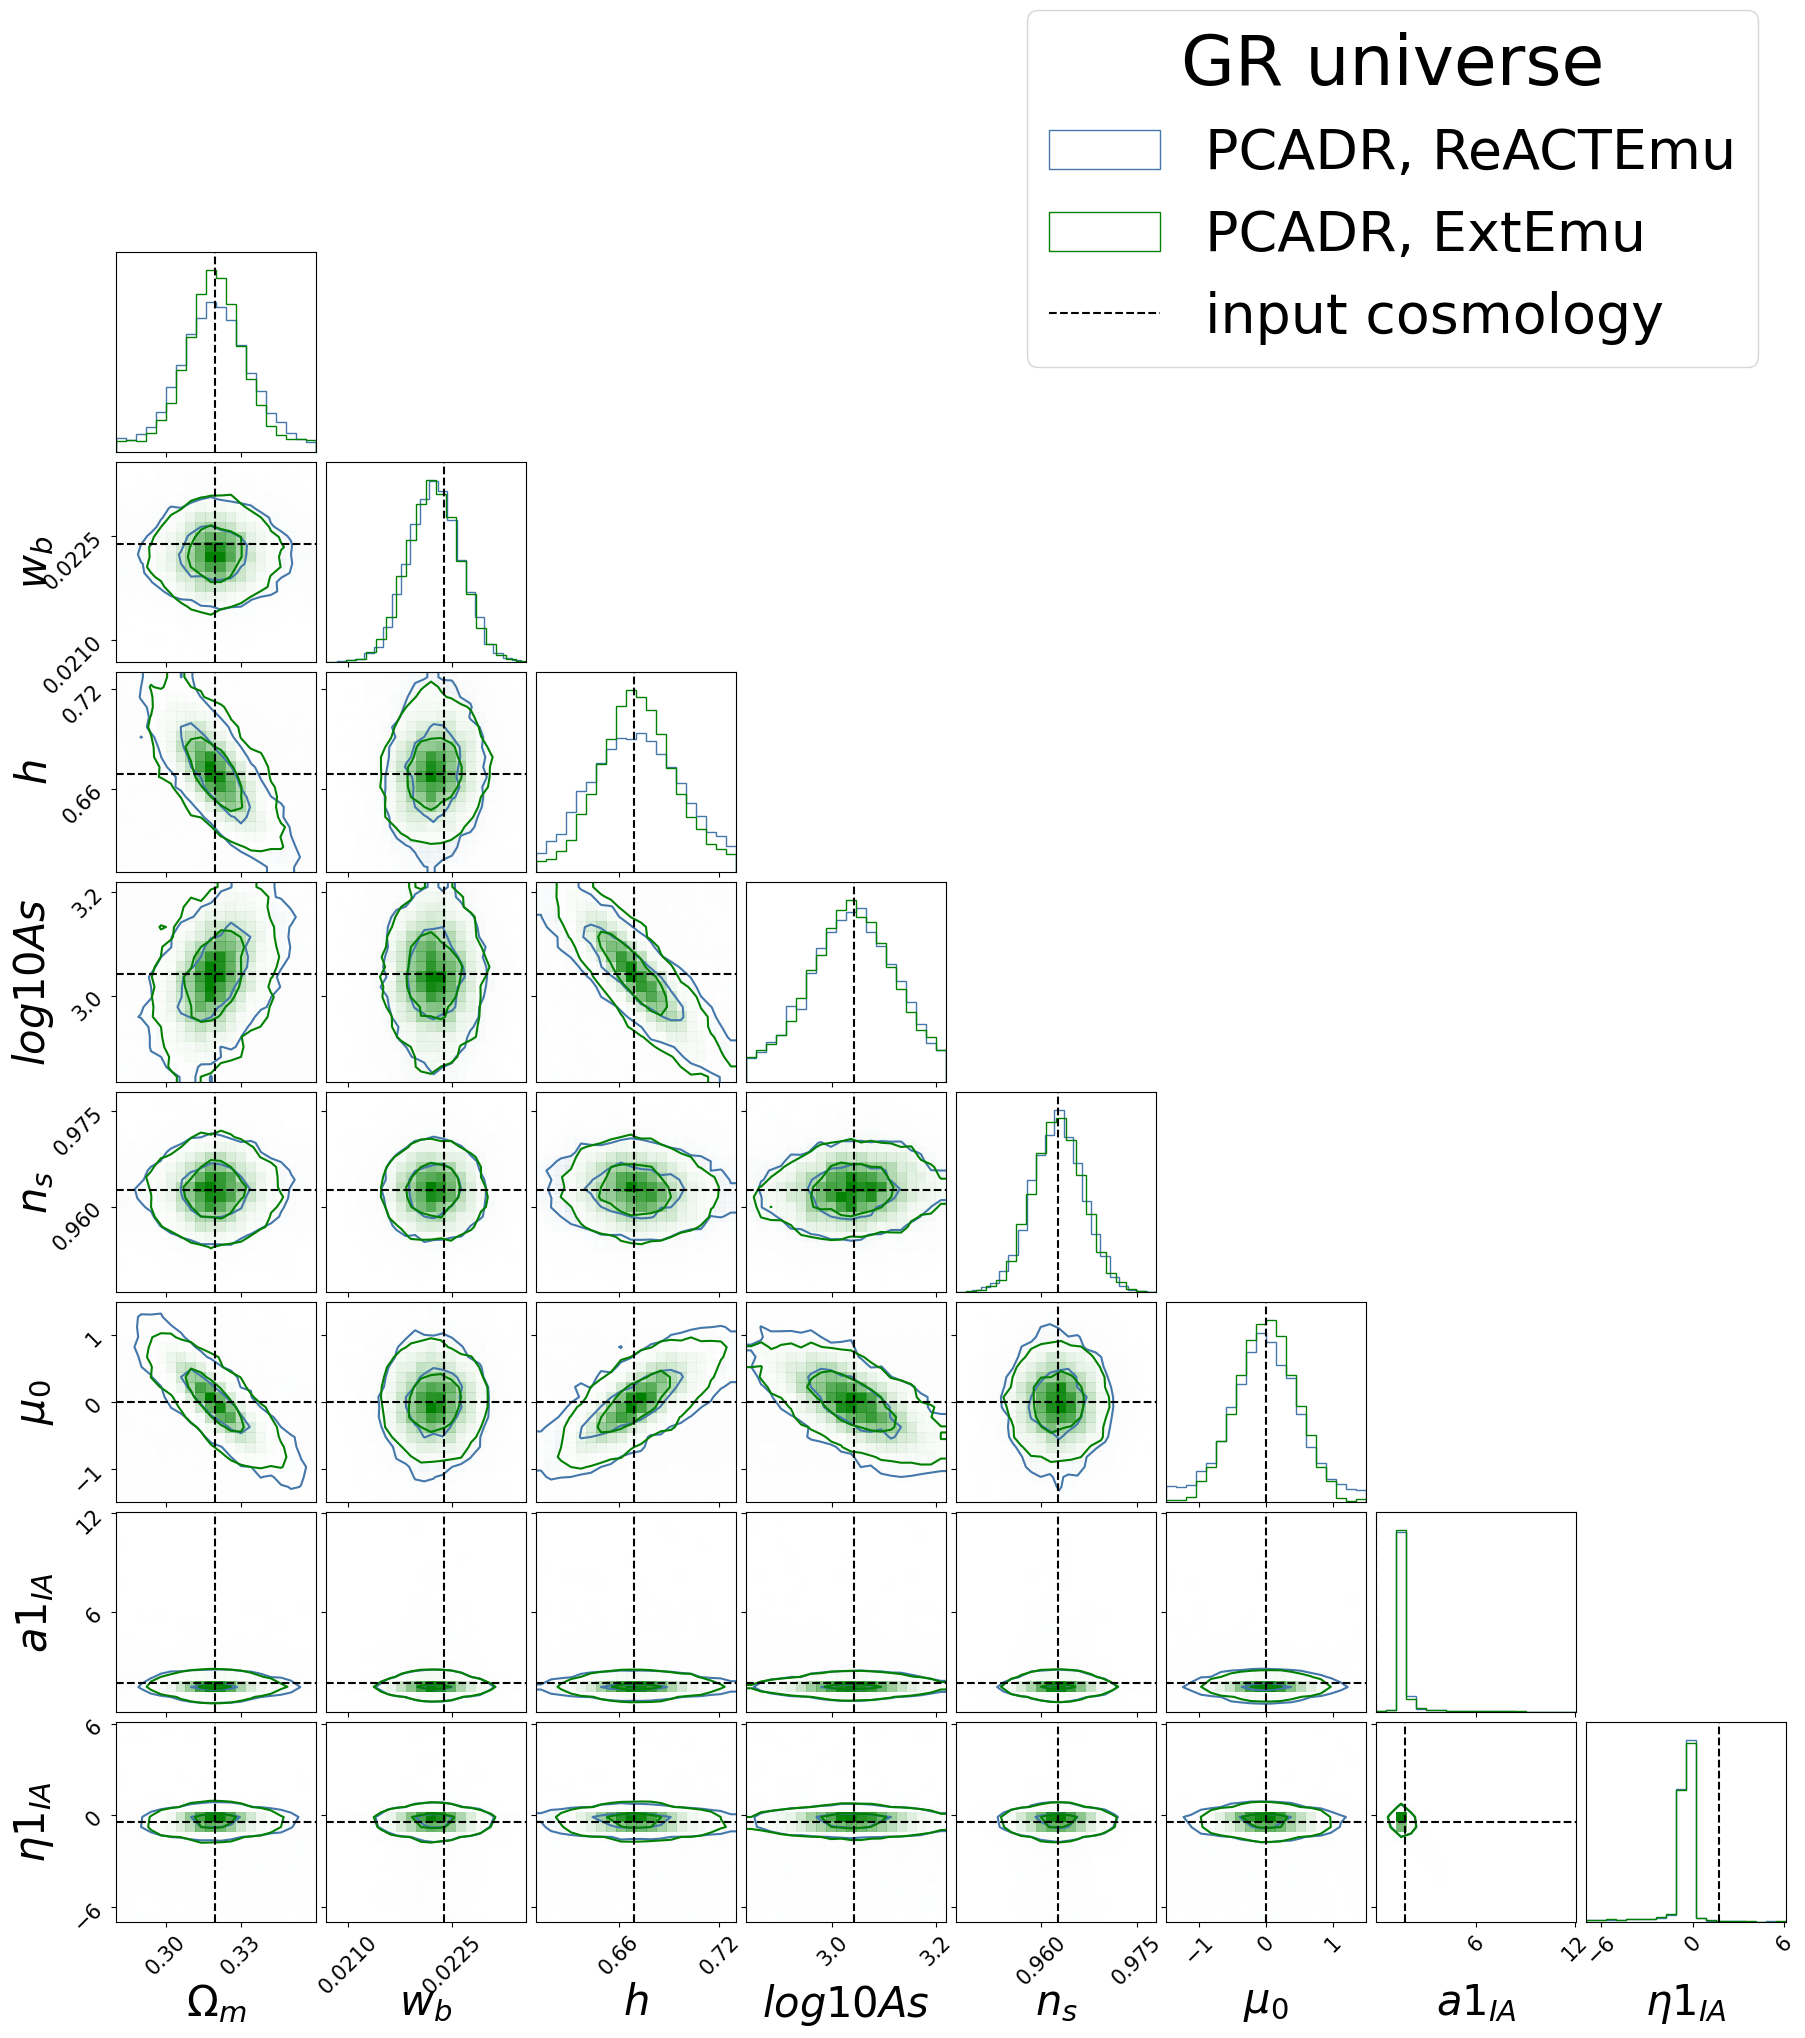

In [174]:
#### STANDARD CUTS #####
ndim = 8
n_params = 8
colors = ["#4477AA","green"]  # Contour colors
truth_color = "k"  # Truth values

ranges = [1.0] * chain_RE[:,:-2].shape[1]
ranges[-2] = (1.5, 2)
ranges[-1] = (-0.75, -0.2)

CORNER_KWARGS = dict(
    #range=ranges,
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

figure = corner.corner(chain_RE[:,:-2], labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[0])

corner.corner(chain_EE[:,:-2], fig=figure, labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[1])


######################
# Extract the axes


axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value2[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value2[xi], color=truth_color, GR_linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value2[xi], color=truth_color, linestyle="--")
            ax.axhline(value2[yi], color=truth_color, linestyle="--")
########################

for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size

#plt.legend(["3x2pt, Existing method (linear scale cuts)","maximum likelihood \n (for PCA-based cuts)","3x2pt, Our method (PCA-based cuts)","input cosmology"],\
#           bbox_to_anchor=(1.0, 12.7), fontsize=40,title=r"GR universe",title_fontsize=60)
plt.legend(["PCADR, ReACTEmu","PCADR, ExtEmu", "input cosmology"], bbox_to_anchor=(1.0, 9.7), fontsize=40,title=r"GR universe",title_fontsize=50)
#"maximum likelihood \n (for PCA-based cuts)"
#plt.savefig("/home/c2042999/MGLensing/pca_emcee_runs/Figures/WL_fR_PCA_comparison_emus.pdf", bbox_inches='tight')


### Plot 4: Compare ReACTEmu PCA with ExtEmu PCA - f(R) data from ReACTEmu

In [175]:
chain_RE = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_fR_lsst_y1_pcacuts_ext.txt")
chain_EE = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_fR_lsst_y1_pcacuts_ReACTemus.txt")

labels1 = [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]

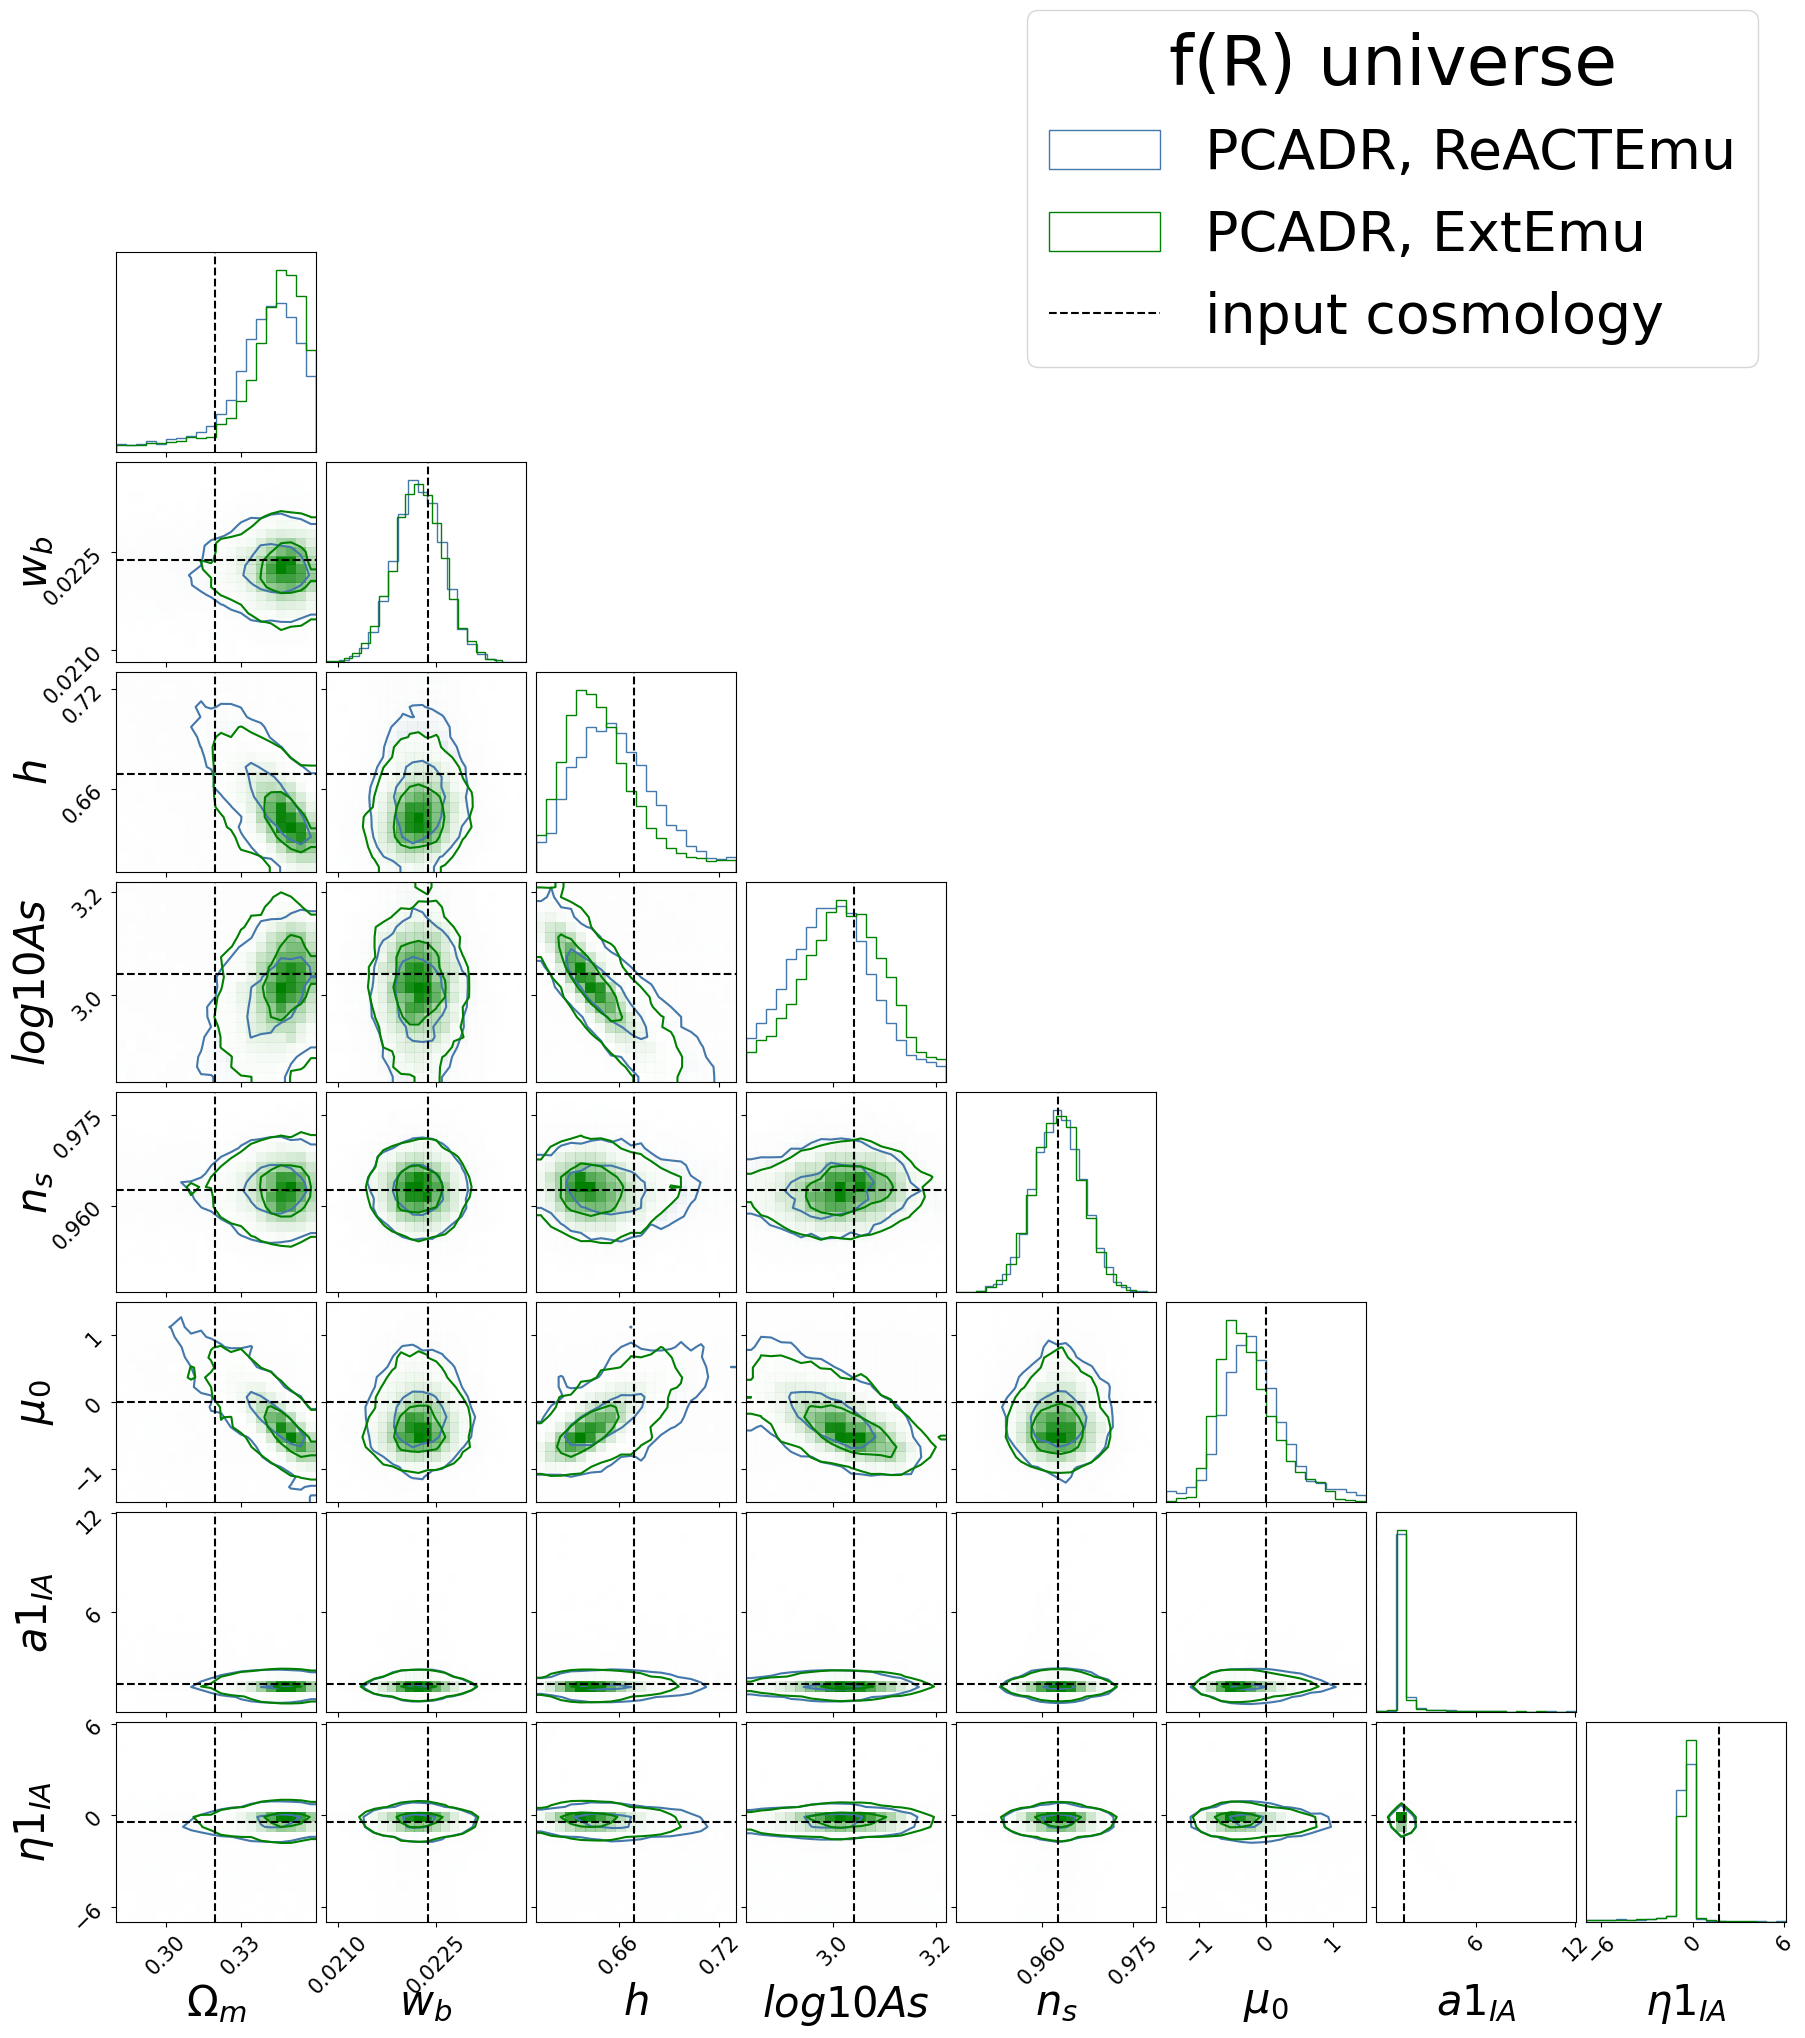

In [176]:
#### STANDARD CUTS #####
ndim = 8
n_params = 8
colors = ["#4477AA","green"]  # Contour colors
truth_color = "k"  # Truth values

ranges = [1.0] * chain_RE[:,:-2].shape[1]
ranges[-2] = (1.5, 2)
ranges[-1] = (-0.75, -0.2)

CORNER_KWARGS = dict(
    #range=ranges,
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

figure = corner.corner(chain_RE[:,:-2], labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[0])

corner.corner(chain_EE[:,:-2], fig=figure, labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[1])


######################
# Extract the axes


axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value2[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value2[xi], color=truth_color, GR_linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value2[xi], color=truth_color, linestyle="--")
            ax.axhline(value2[yi], color=truth_color, linestyle="--")
########################

for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size

#plt.legend(["3x2pt, Existing method (linear scale cuts)","maximum likelihood \n (for PCA-based cuts)","3x2pt, Our method (PCA-based cuts)","input cosmology"],\
#           bbox_to_anchor=(1.0, 12.7), fontsize=40,title=r"GR universe",title_fontsize=60)
plt.legend(["PCADR, ReACTEmu","PCADR, ExtEmu", "input cosmology"], bbox_to_anchor=(1.0, 9.7), fontsize=40,title=r"f(R) universe",title_fontsize=50)
#"maximum likelihood \n (for PCA-based cuts)"
#plt.savefig("/home/c2042999/MGLensing/pca_emcee_runs/Figures/WL_fR_PCA_comparison_emus.pdf", bbox_inches='tight')


### Plot 5: Compare ReACTEmu PCA with f(R) data from ReACTEmu vs. from ExtEmu

In [177]:
chain_RE = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_fR_ReactEmu_lsst_y1_pcacuts_ReACTemus.txt")
chain_EE = np.loadtxt("/home/c2042999/MGLensing/pca_emcee_runs/chains/chain_fR_lsst_y1_pcacuts_ReACTemus.txt")

labels1 = [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]


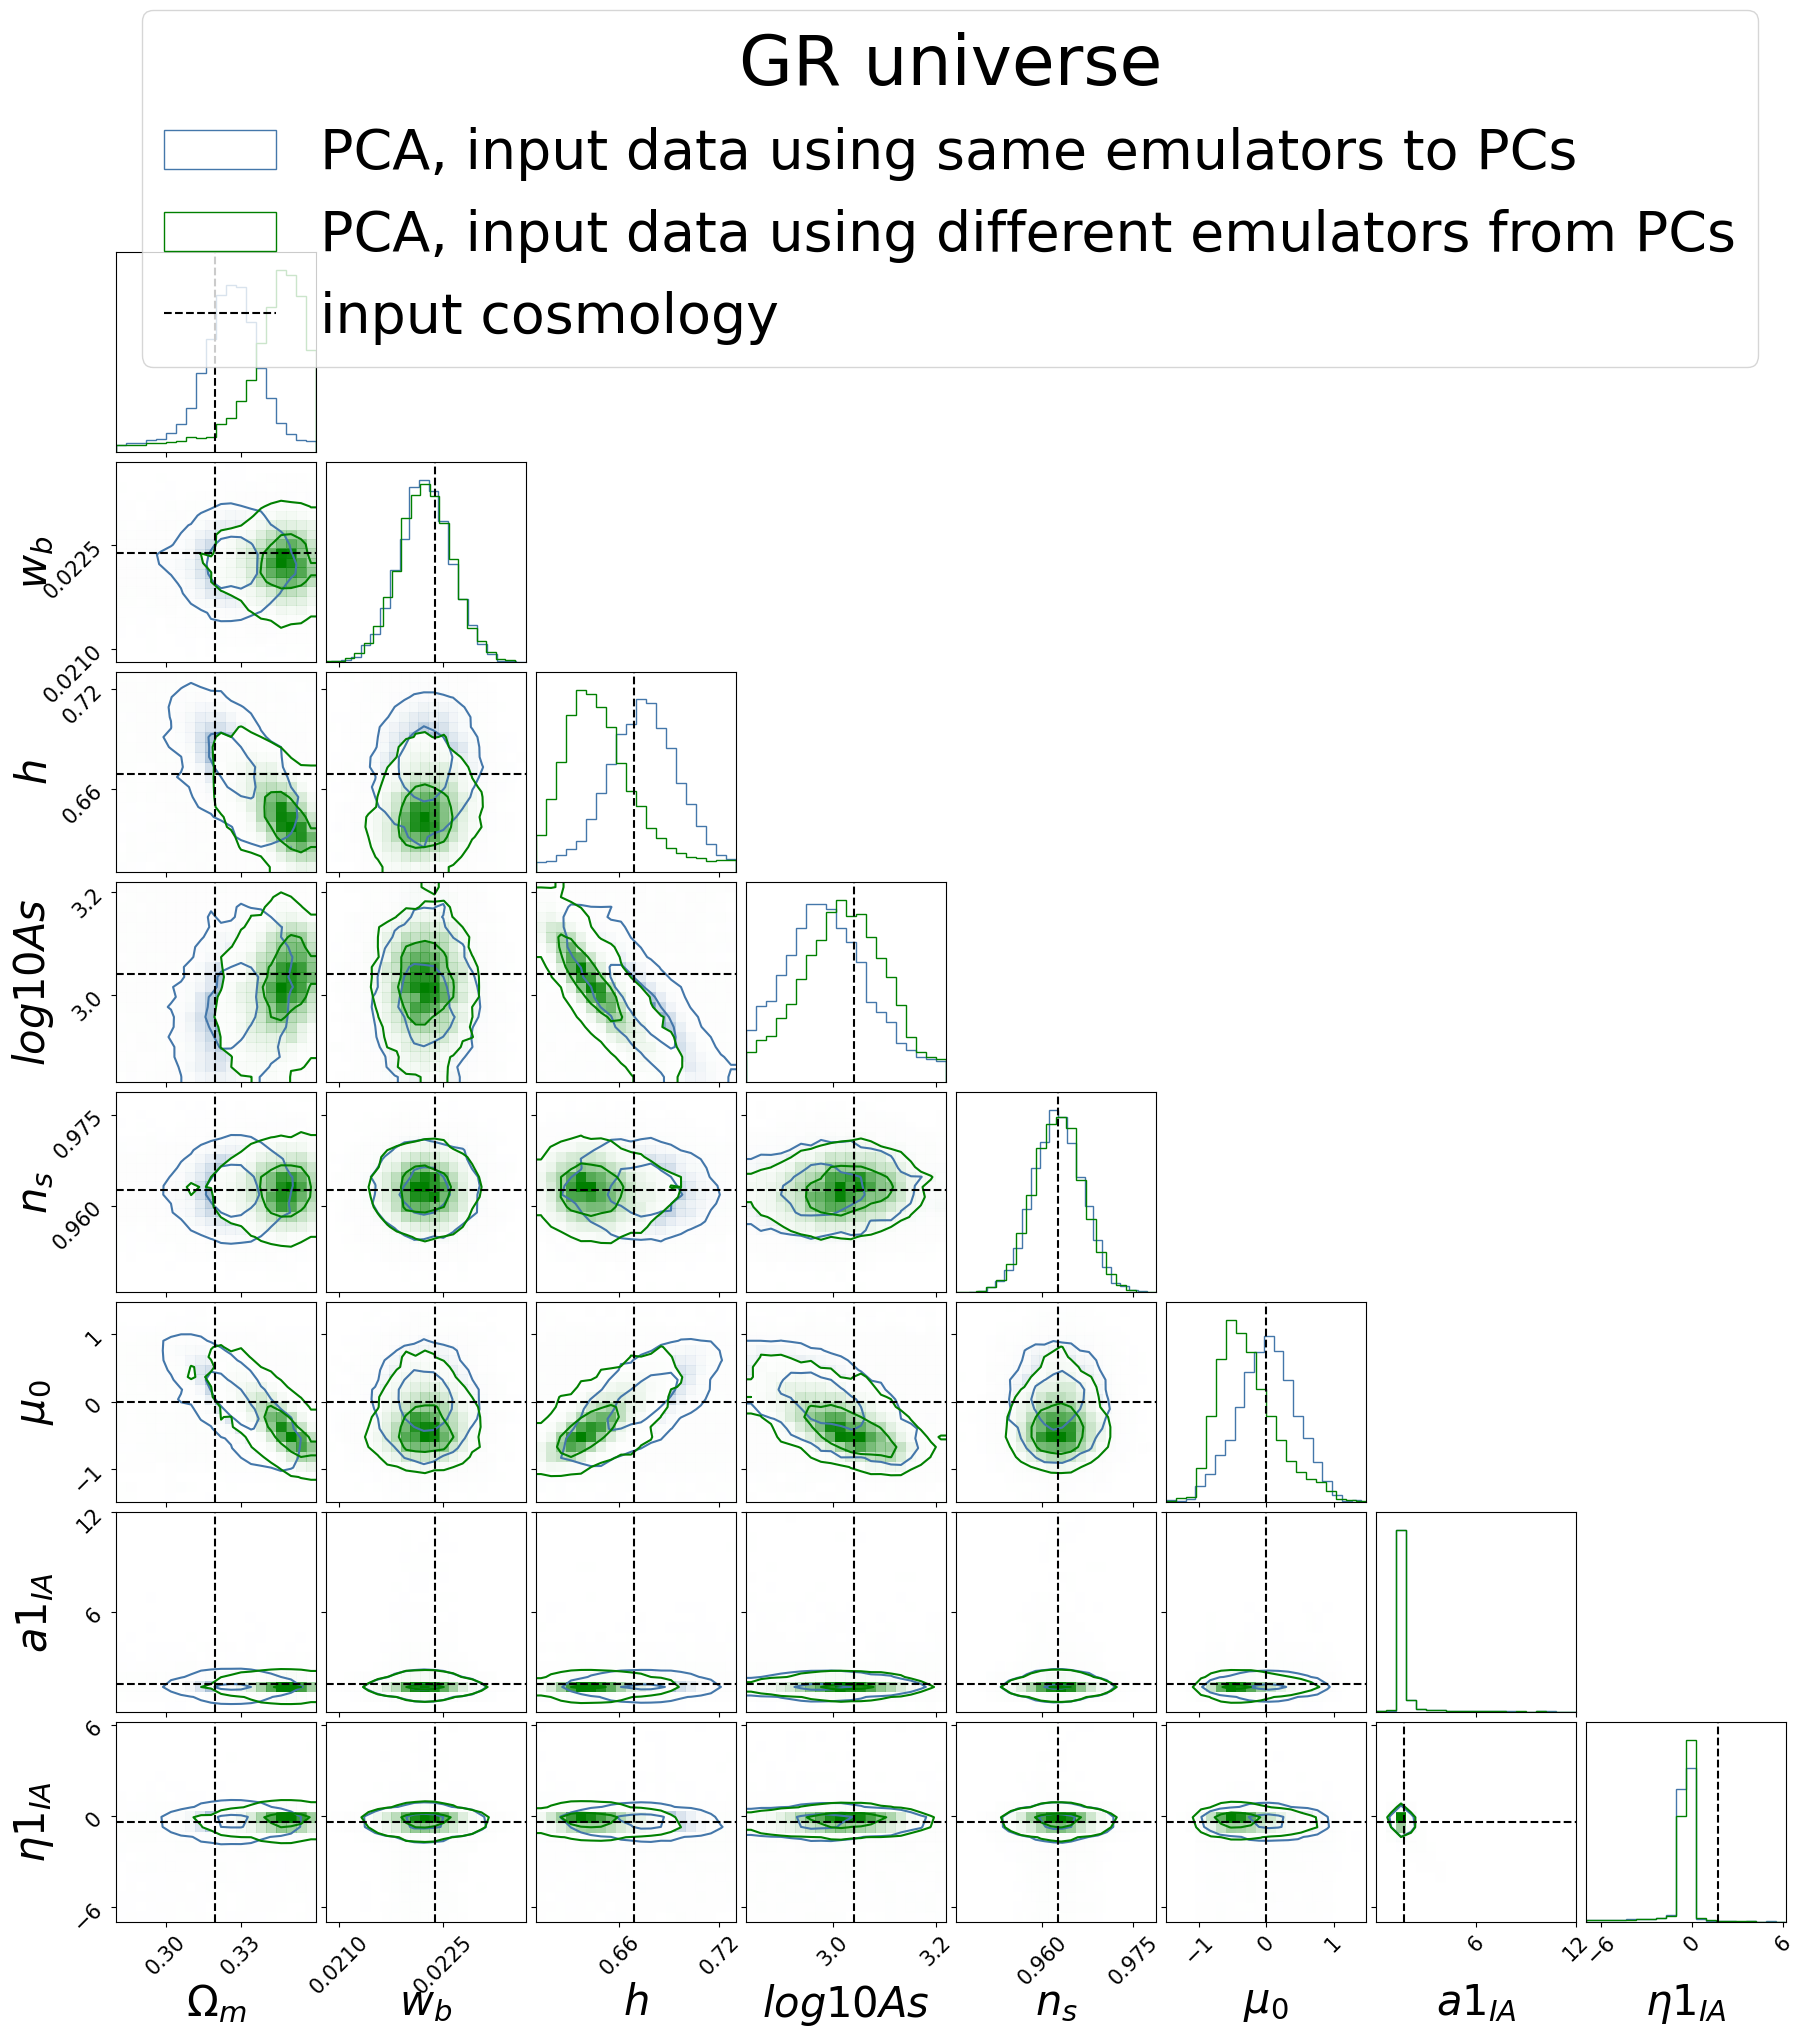

In [178]:
#### STANDARD CUTS #####
ndim = 8
n_params = 8
colors = ["#4477AA","green"]  # Contour colors
truth_color = "k"  # Truth values

ranges = [1.0] * chain_RE[:,:-2].shape[1]
ranges[-2] = (1.5, 2)
ranges[-1] = (-0.75, -0.2)

CORNER_KWARGS = dict(
    #range=ranges,
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=False,
    smooth = 0.5,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=False,
    max_n_ticks=2,
    title_fmt=".3f"
)

figure = corner.corner(chain_RE[:,:-2], labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[0])

corner.corner(chain_EE[:,:-2], fig=figure, labels=labels1, **CORNER_KWARGS,hist_kwargs=dict(density=True), color = colors[1])


######################
# Extract the axes


axes = np.array(figure.axes).reshape((ndim, ndim))

# Loop over the diagonal
for i in range(ndim):
    if value1[i] != None:
        ax = axes[i, i]
        ax.axvline(value1[i], color=truth_color, linestyle="--")

# Loop over histograms
for yi in range(ndim):
    for xi in range(yi):
        if value1[xi] == None:
            ax = axes[yi, xi]
            ax.axhline(value2[yi], color=truth_color, linestyle="--")
        elif value1[yi] == None:
            ax = axes[yi, xi]
            ax.axvline(value2[xi], color=truth_color, GR_linestyle="--")
        else:
            ax = axes[yi, xi]
            ax.axvline(value2[xi], color=truth_color, linestyle="--")
            ax.axhline(value2[yi], color=truth_color, linestyle="--")
########################

for ax in figure.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=15)  # Change label size

#plt.legend(["3x2pt, Existing method (linear scale cuts)","maximum likelihood \n (for PCA-based cuts)","3x2pt, Our method (PCA-based cuts)","input cosmology"],\
#           bbox_to_anchor=(1.0, 12.7), fontsize=40,title=r"GR universe",title_fontsize=60)
plt.legend(["PCA, input data using same emulators to PCs","PCA, input data using different emulators from PCs", "input cosmology"], bbox_to_anchor=(1.0, 9.7), fontsize=40,title=r"GR universe",title_fontsize=50)
#"maximum likelihood \n (for PCA-based cuts)"
#plt.savefig("/home/c2042999/MGLensing/pca_emcee_runs/Figures/WL_fR_PCA_comparison_emus.pdf", bbox_inches='tight')
